<a href="https://colab.research.google.com/github/contactyuvrajchand-droid/machine_learning_lab/blob/main/Week_4_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Titanic Survival Prediction using PySpark Logistic Regression
This notebook follows the supplied diabetes example and adapts it to the Titanic dataset.

## Step 1 — Install PySpark

In [ ]:
!pip -q install pyspark

## Step 2 — Create a Spark session

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession \
    .builder \
    .appName("Titanic Logistic Regression") \
    .config("spark.some.config.option", "some-value") \
    .getOrCreate()

## Step 3 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 4 — Load the Titanic dataset
Change the path below if your CSV is stored in a different Drive folder.

In [ ]:
dataset = spark.read.csv(
    'drive/My Drive/Colab Notebooks/lab4/titanic_synthetic_data.csv',
    inferSchema=True,
    header=True
)

print(dataset.columns)
dataset.printSchema()
dataset.describe().show()

['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex', 'Survived', 'Embarked_Q', 'Embarked_S']
root
 |-- Pclass: integer (nullable = true)
 |-- Age: integer (nullable = true)
 |-- SibSp: integer (nullable = true)
 |-- Parch: integer (nullable = true)
 |-- Fare: double (nullable = true)
 |-- Sex: integer (nullable = true)
 |-- Survived: integer (nullable = true)
 |-- Embarked_Q: integer (nullable = true)
 |-- Embarked_S: integer (nullable = true)

+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+
|summary|            Pclass|               Age|             SibSp|             Parch|              Fare|               Sex|          Survived|         Embarked_Q|        Embarked_S|
+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+
|  coun

## Step 5 — Check missing values

In [ ]:
from pyspark.sql.functions import col, isnan, when, count

dataset.select([
    count(when(isnan(c) | col(c).isNull(), c)).alias(c)
    for c in dataset.columns
]).show()

+------+---+-----+-----+----+---+--------+----------+----------+
|Pclass|Age|SibSp|Parch|Fare|Sex|Survived|Embarked_Q|Embarked_S|
+------+---+-----+-----+----+---+--------+----------+----------+
|     0|  0|    0|    0|   0|  0|       0|         0|         0|
+------+---+-----+-----+----+---+--------+----------+----------+



## Step 6 — Clean invalid values
Only `Age = 0` is changed to NaN. Zero in `SibSp` or `Parch` is valid for Titanic and must not be removed.

In [ ]:
import numpy as np

dataset = dataset.withColumn(
    "Age",
    when(dataset.Age == 0, np.nan).otherwise(dataset.Age)
)

dataset.select("Pclass", "Age", "SibSp", "Parch", "Fare").show(5)

+------+----+-----+-----+------------------+
|Pclass| Age|SibSp|Parch|              Fare|
+------+----+-----+-----+------------------+
|     3|42.0|    6|    7|397.00178367782024|
|     1|52.0|    6|    7|302.12770032784186|
|     3|25.0|    3|    8| 427.1058765283985|
|     3|32.0|    9|    7| 326.8049924602327|
|     1|40.0|    0|    5|17.718838497771657|
+------+----+-----+-----+------------------+
only showing top 5 rows


## Step 7 — Impute missing numeric values

In [ ]:
from pyspark.ml.feature import Imputer

imputer = Imputer(
    inputCols=["Age", "Fare", "Pclass", "SibSp", "Parch"],
    outputCols=["Age", "Fare", "Pclass", "SibSp", "Parch"]
)

imputer_model = imputer.fit(dataset)
dataset = imputer_model.transform(dataset)
dataset.show(5)

+------+----+-----+-----+------------------+---+--------+----------+----------+
|Pclass| Age|SibSp|Parch|              Fare|Sex|Survived|Embarked_Q|Embarked_S|
+------+----+-----+-----+------------------+---+--------+----------+----------+
|     3|42.0|    6|    7|397.00178367782024|  0|       0|         0|         1|
|     1|52.0|    6|    7|302.12770032784186|  0|       0|         1|         0|
|     3|25.0|    3|    8| 427.1058765283985|  1|       1|         1|         0|
|     3|32.0|    9|    7| 326.8049924602327|  1|       0|         0|         0|
|     1|40.0|    0|    5|17.718838497771657|  0|       0|         0|         0|
+------+----+-----+-----+------------------+---+--------+----------+----------+
only showing top 5 rows


## Binning Continuous Features
To address the issue with `ChiSqSelector` expecting categorical features, we will bin the 'Fare' column. Binning converts a continuous numerical feature into a set of discrete, ordered bins (categories).

In [ ]:
from pyspark.ml.feature import Bucketizer

# Define splits for the 'Fare' column. The splits define the boundaries of the bins.
# You can choose these based on domain knowledge or data distribution (e.g., quantiles).
# Ensure that the min and max values of 'Fare' from dataset.describe().show() are covered.
# Fare ranges from 10.00 to 499.99.
# Let's create 5 bins:
# (-inf, 50], (50, 100], (100, 200], (200, 350], (350, +inf)
splits_fare = [float('-inf'), 50.0, 100.0, 200.0, 350.0, float('inf')]

# Create a Bucketizer instance for Fare
bucketizer_fare = Bucketizer(
    splits=splits_fare,
    inputCol="Fare",
    outputCol="Fare_Binned"
)

# Transform the dataset to add the binned 'Fare' column
# Check if 'Fare_Binned' already exists to prevent error on re-run
if "Fare_Binned" not in dataset.columns:
    dataset = bucketizer_fare.transform(dataset)

# Define splits for the 'Age' column.
# Age ranges from 0 to 79. Let's create sensible bins.
# (-inf, 18], (18, 30], (30, 50], (50, 65], (65, +inf)
splits_age = [float('-inf'), 18.0, 30.0, 50.0, 65.0, float('inf')]

# Create a Bucketizer instance for Age
bucketizer_age = Bucketizer(
    splits=splits_age,
    inputCol="Age",
    outputCol="Age_Binned"
)

# Transform the dataset to add the binned 'Age' column
# Check if 'Age_Binned' already exists to prevent error on re-run
if "Age_Binned" not in dataset.columns:
    dataset = bucketizer_age.transform(dataset)

# Display the original and binned columns to verify
dataset.select("Fare", "Fare_Binned", "Age", "Age_Binned").show(5)

# It's crucial to now remove 'Fare' and 'Age' from `feature_columns` and add 'Fare_Binned' and 'Age_Binned'
# The subsequent steps (VectorAssembler, StandardScaler, ChiSqSelector) will need to be re-run.

+------------------+-----------+----+----------+
|              Fare|Fare_Binned| Age|Age_Binned|
+------------------+-----------+----+----------+
|397.00178367782024|        4.0|42.0|       2.0|
|302.12770032784186|        3.0|52.0|       3.0|
| 427.1058765283985|        4.0|25.0|       1.0|
| 326.8049924602327|        3.0|32.0|       2.0|
|17.718838497771657|        0.0|40.0|       2.0|
+------------------+-----------+----+----------+
only showing top 5 rows


## Step 8 — Assemble the feature vector

In [ ]:
from pyspark.ml.feature import VectorAssembler

# Define the correct list of feature columns for the assembler.
# Replace 'Fare' with 'Fare_Binned' and 'Age' with 'Age_Binned', exclude 'Survived' as it's the label.
# Ensure 'features' and 'Scaled_features' are not accidentally included as inputs
# if this cell is run after StandardScaler.
input_cols_for_assembler = [
    'Pclass', 'Age_Binned', 'SibSp', 'Parch', 'Sex', 'Embarked_Q', 'Embarked_S', 'Fare_Binned'
]

# Drop existing 'features' and 'Scaled_features' columns if they exist
# This prevents the 'Output column features already exists' error if the cell is run multiple times.
if "features" in dataset.columns:
    dataset = dataset.drop("features")
if "Scaled_features" in dataset.columns:
    dataset = dataset.drop("Scaled_features")

assembler = VectorAssembler(
    inputCols=input_cols_for_assembler,
    outputCol="features"
)

dataset = assembler.transform(dataset)
dataset.select("features").show(5, truncate=False)

# Update the global 'feature_columns' list to reflect the features used for assembly.
# This list is used by ChiSqSelector later.
feature_columns = input_cols_for_assembler.copy()

+---------------------------------+
|features                         |
+---------------------------------+
|[3.0,2.0,6.0,7.0,0.0,0.0,1.0,4.0]|
|[1.0,3.0,6.0,7.0,0.0,1.0,0.0,3.0]|
|[3.0,1.0,3.0,8.0,1.0,1.0,0.0,4.0]|
|[3.0,2.0,9.0,7.0,1.0,0.0,0.0,3.0]|
|(8,[0,1,3],[1.0,2.0,5.0])        |
+---------------------------------+
only showing top 5 rows


## Step 9 — Standardise the features

In [ ]:
from pyspark.ml.feature import StandardScaler

# Drop existing 'Scaled_features' if it exists to prevent errors on re-run
if "Scaled_features" in dataset.columns:
    dataset = dataset.drop("Scaled_features")

standardscaler = (
    StandardScaler()
    .setInputCol("features")
    .setOutputCol("Scaled_features")
)

scaler_model = standardscaler.fit(dataset)
dataset = scaler_model.transform(dataset)
dataset.select("features", "Scaled_features").show(5)


+--------------------+--------------------+
|            features|     Scaled_features|
+--------------------+--------------------+
|[3.0,2.0,6.0,7.0,...|[3.67275115824148...|
|[1.0,3.0,6.0,7.0,...|[1.22425038608049...|
|[3.0,1.0,3.0,8.0,...|[3.67275115824148...|
|[3.0,2.0,9.0,7.0,...|[3.67275115824148...|
|(8,[0,1,3],[1.0,2...|(8,[0,1,3],[1.224...|
+--------------------+--------------------+
only showing top 5 rows


## Step 10 — Split the dataset

In [ ]:
train, test = dataset.randomSplit([0.8, 0.2], seed=12345)
print("Training rows:", train.count())
print("Testing rows:", test.count())


Training rows: 800244
Testing rows: 199756


## Step 11 — Calculate class weights

In [ ]:
dataset_size = float(train.select("Survived").count())
numPositives = train.select("Survived").where('Survived == 1').count()
per_ones = (float(numPositives) / dataset_size) * 100
numNegatives = float(dataset_size - numPositives)

print('The number of ones are {}'.format(numPositives))
print('Percentage of ones are {}'.format(per_ones))

BalancingRatio = numNegatives / dataset_size
print('BalancingRatio = {}'.format(BalancingRatio))

train = train.withColumn(
    "classWeights",
    when(train.Survived == 1, BalancingRatio)
    .otherwise(1 - BalancingRatio)
)
train.select("classWeights").show(5)


The number of ones are 399854
Percentage of ones are 49.96651021438461
BalancingRatio = 0.5003348978561539
+------------------+
|      classWeights|
+------------------+
|0.5003348978561539|
|0.4996651021438461|
|0.5003348978561539|
|0.5003348978561539|
|0.4996651021438461|
+------------------+
only showing top 5 rows


## Step 12 — Feature selection using ChiSqSelector
The selector is fitted once on the training data and then used on both datasets. This avoids learning from the test set.

In [ ]:
from pyspark.ml.feature import ChiSqSelector

css = ChiSqSelector(
    featuresCol='Scaled_features',
    outputCol='Aspect',
    labelCol='Survived',
    selectorType='numTopFeatures',
    numTopFeatures=min(7, len(feature_columns))
)

css_model = css.fit(train)
train = css_model.transform(train)
test = css_model.transform(test)

print("Selected feature indices:", css_model.selectedFeatures)
print("Selected feature names:", [
    feature_columns[i] for i in css_model.selectedFeatures
])
test.select("Aspect").show(5, truncate=False)



Selected feature indices: [0, 1, 3, 4, 5, 6, 7]
Selected feature names: ['Pclass', 'Age_Binned', 'Parch', 'Sex', 'Embarked_Q', 'Embarked_S', 'Fare_Binned']
+-----------------------------------------------------------------------+
|Aspect                                                                 |
+-----------------------------------------------------------------------+
|(7,[0,6],[1.2242503860804963,1.6142452694699703])                      |
|(7,[0,3,6],[1.2242503860804963,2.0000016896038306,3.2284905389399405]) |
|(7,[0,2],[1.2242503860804963,0.34809122750702337])                     |
|(7,[0,2,6],[1.2242503860804963,0.34809122750702337,0.8071226347349851])|
|(7,[0,2,6],[1.2242503860804963,0.34809122750702337,2.4213679042049554])|
+-----------------------------------------------------------------------+
only showing top 5 rows


## Step 13 — Fit the Logistic Regression Model

In [ ]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    labelCol="Survived",
    featuresCol="Aspect", # Using the features selected by ChiSqSelector
    weightCol="classWeights",
    maxIter=100,
    regParam=0.01,
    elasticNetParam=0.0
)

model = lr.fit(train)
predict_train = model.transform(train)
predict_test = model.transform(test)
predict_test.select("Survived", "prediction").show(10)

+--------+----------+
|Survived|prediction|
+--------+----------+
|       0|       1.0|
|       0|       0.0|
|       0|       1.0|
|       0|       1.0|
|       0|       1.0|
|       0|       1.0|
|       0|       1.0|
|       1|       0.0|
|       1|       0.0|
|       1|       1.0|
+--------+----------+
only showing top 10 rows


## Step 14 — Evaluate AUROC and test accuracy

In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

roc_evaluator = BinaryClassificationEvaluator(
    rawPredictionCol='rawPrediction',
    labelCol="Survived",
    metricName="areaUnderROC"
)
auroc = roc_evaluator.evaluate(predict_test)

accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="Survived",
    predictionCol="prediction",
    metricName="accuracy"
)
test_accuracy = accuracy_evaluator.evaluate(predict_test)

print("Area under ROC Curve: {:.4f}".format(auroc))
print("Model Test Accuracy: {:.2f}%".format(test_accuracy * 100))
predict_test.select("Survived", "prediction", "probability").show(15)

Area under ROC Curve: 0.4974
Model Test Accuracy: 49.74%
+--------+----------+--------------------+
|Survived|prediction|         probability|
+--------+----------+--------------------+
|       0|       1.0|[0.49924415915528...|
|       0|       0.0|[0.50194707921321...|
|       0|       1.0|[0.49780436165819...|
|       0|       1.0|[0.49852757919126...|
|       0|       1.0|[0.49997402971482...|
|       0|       1.0|[0.49906746806759...|
|       0|       1.0|[0.49892529530664...|
|       1|       0.0|[0.50240409646911...|
|       1|       0.0|[0.50196701014383...|
|       1|       1.0|[0.49947182964479...|
|       1|       0.0|[0.50097094648621...|
|       0|       0.0|[0.50116092470434...|
|       1|       0.0|[0.50116092470434...|
|       1|       0.0|[0.50197365378598...|
|       0|       0.0|[0.50020170057266...|
+--------+----------+--------------------+
only showing top 15 rows


## Step 15 — Plot the precision-recall curve

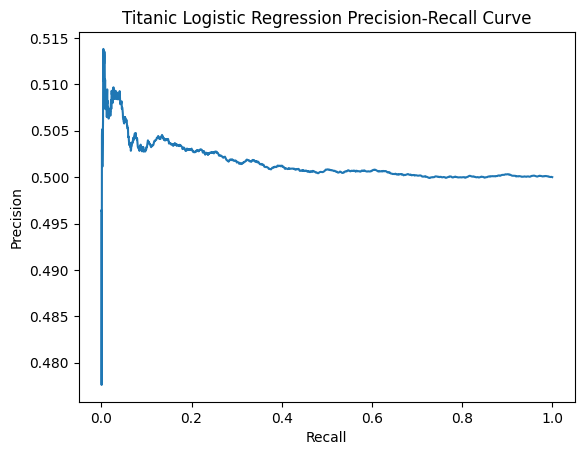

Training Accuracy 0.5004014767919945
Test Accuracy 0.497396824125433
FP rate [0.5195996538736813, 0.4795973925422896]
TR rate [0.5204026074577105, 0.48040034612631854]


In [ ]:
import matplotlib.pyplot as plt

pr_curve = model.summary.pr.toPandas()
plt.plot(pr_curve['recall'], pr_curve['precision'])
plt.ylabel('Precision')
plt.xlabel('Recall')
plt.title('Titanic Logistic Regression Precision-Recall Curve')
plt.show()

print("Training Accuracy", model.summary.accuracy)
print("Test Accuracy", test_accuracy)
print("FP rate", model.summary.falsePositiveRateByLabel)
print("TR rate", model.summary.truePositiveRateByLabel)

## Step 16 — Calculate the confusion matrix

In [ ]:
prediction_data = predict_test.select("Survived", "prediction").toPandas()

TruePositive = 0
FalsePositive = 0
TrueNegative = 0
FalseNegative = 0
Positive = 1.0
Negative = 0.0

print("Total", len(prediction_data["Survived"]))

for row in range(len(prediction_data["Survived"])):
    actual = prediction_data["Survived"][row]
    predicted = prediction_data["prediction"][row]

    if predicted == Positive:
        if predicted == actual:
            TruePositive += 1
        else:
            FalsePositive += 1
    elif predicted == Negative:
        if predicted == actual:
            TrueNegative += 1
        else:
            FalseNegative += 1

print("TruePositive", TruePositive, "FalsePositive", FalsePositive)
print("TrueNegative", TrueNegative, "FalseNegative", FalseNegative)

Total 199756
TruePositive 47675 FalsePositive 48057
TrueNegative 51683 FalseNegative 52341


## Step 17 — Plot the confusion matrix and calculate precision, recall and F1-score

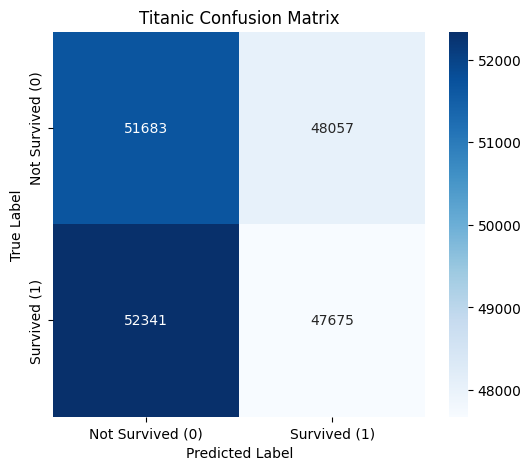

Precision: 0.4980
Recall:    0.4767
F1-score:  0.4871


In [ ]:
import seaborn as sns

TN = TrueNegative
FP = FalsePositive
FN = FalseNegative
TP = TruePositive

conf_matrix = np.array([[TN, FP], [FN, TP]])
labels = ["Not Survived (0)", "Survived (1)"]

plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Titanic Confusion Matrix")
plt.show()

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) > 0 else 0
)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1_score:.4f}")